# MISION: Primer Vuelo

**Objetivo:** Entrenar modelos clasicos de ML para predecir la Vida Util Restante (RUL). Este es un problema de **REGRESION**, no de clasificacion — predecimos un numero (ciclos restantes).

---

### Modelos a evaluar
1. **Baseline naive:** predecir la media global del RUL
2. **Linear Regression:** baseline lineal
3. **Random Forest Regressor:** ensemble de arboles
4. **XGBoost Regressor:** gradient boosting
5. **SVR:** Support Vector Regression

### Metricas
- **RMSE:** Error cuadratico medio (penaliza errores grandes)
- **MAE:** Error absoluto medio (mas robusto a outliers)
- **R2:** Varianza explicada
- **NASA Score:** Funcion asimetrica que penaliza mas las predicciones tardias (decir que al motor le quedan mas ciclos de los que realmente le quedan)

## 1. Imports y Carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
HEALTHY = '#2ecc71'
DEGRADED = '#f39c12'
CRITICAL = '#e74c3c'
NEUTRAL = '#3498db'

import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
processed_dir = os.path.join(project_root, "data", "cmapss", "processed")
models_dir = os.path.join(project_root, "models")
os.makedirs(models_dir, exist_ok=True)

In [2]:
# Cargar datos procesados
df_train = pd.read_parquet(os.path.join(processed_dir, 'train_features.parquet'))
df_test_last = pd.read_parquet(os.path.join(processed_dir, 'test_last_cycle.parquet'))

# Separar features y target
feature_cols = [c for c in df_train.columns if c not in ['unit', 'time_cycles', 'RUL']]
X_train = df_train[feature_cols].values
y_train = df_train['RUL'].values

X_test = df_test_last[feature_cols].values
y_test = df_test_last['RUL'].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Features: {len(feature_cols)}")

X_train: (20631, 58), y_train: (20631,)
X_test: (100, 58), y_test: (100,)
Features: 58


## 2. NASA Scoring Function

La funcion de scoring de la NASA penaliza **asimetricamente**: predecir tarde (optimista) es PEOR que predecir temprano (conservador).

- Si prediccion > real (late): penalizacion exponencial con factor 10
- Si prediccion < real (early): penalizacion exponencial con factor 13

Logica: si dices que al motor le quedan 50 ciclos y realmente le quedan 20, el avion puede caer. Mejor ser conservador.

In [3]:
def nasa_score(y_true, y_pred):
    """
    NASA Scoring Function para C-MAPSS.
    d = y_pred - y_true (predicho - real)
    d < 0: prediccion temprana (early) -> s = exp(-d/13) - 1
    d >= 0: prediccion tardia (late) -> s = exp(d/10) - 1
    """
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(scores)

def evaluate_model(y_true, y_pred, model_name):
    """Evaluar un modelo con todas las metricas."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    score = nasa_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  RMSE:       {rmse:.2f} ciclos")
    print(f"  MAE:        {mae:.2f} ciclos")
    print(f"  R2:         {r2:.4f}")
    print(f"  NASA Score: {score:,.0f} (menor es mejor)")
    
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NASA_Score': score}

## 3. Baseline Naive

Predecir siempre la media del RUL de entrenamiento. Cualquier modelo decente debe superar esto.

In [4]:
# Baseline: predecir la media
y_pred_naive = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
results = []
results.append(evaluate_model(y_test, y_pred_naive, "Baseline (Media)"))


  Baseline (Media)
  RMSE:       42.97 ciclos
  MAE:        35.33 ciclos
  R2:         -0.1152
  NASA Score: 40,273 (menor es mejor)


## 4. Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate_model(y_test, y_pred_lr, "Linear Regression"))


  Linear Regression
  RMSE:       21.26 ciclos
  MAE:        16.67 ciclos
  R2:         0.7270
  NASA Score: 1,271 (menor es mejor)


## 5. Random Forest Regressor

In [6]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate_model(y_test, y_pred_rf, "Random Forest"))


  Random Forest
  RMSE:       18.70 ciclos
  MAE:        13.70 ciclos
  R2:         0.7887
  NASA Score: 1,209 (menor es mejor)


## 6. XGBoost Regressor

In [7]:
xgb = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, n_jobs=-1,
                   early_stopping_rounds=20)

# Split para early stopping
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
y_pred_xgb = xgb.predict(X_test)
results.append(evaluate_model(y_test, y_pred_xgb, "XGBoost"))


  XGBoost
  RMSE:       18.72 ciclos
  MAE:        13.93 ciclos
  R2:         0.7884
  NASA Score: 879 (menor es mejor)


## 7. SVR (Support Vector Regression)

SVR es mas lento pero puede capturar relaciones no lineales. Usamos un subset para entrenamiento por rendimiento.

In [8]:
from sklearn.preprocessing import StandardScaler

# SVR necesita escalado y subset (es lento con 20k filas)
scaler_svr = StandardScaler()
X_train_scaled = scaler_svr.fit_transform(X_train)
X_test_scaled = scaler_svr.transform(X_test)

# Usar subset para entrenar SVR (5000 muestras)
np.random.seed(42)
idx = np.random.choice(len(X_train_scaled), size=min(5000, len(X_train_scaled)), replace=False)
X_train_svr = X_train_scaled[idx]
y_train_svr = y_train[idx]

svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=5)
svr.fit(X_train_svr, y_train_svr)
y_pred_svr = svr.predict(X_test_scaled)
results.append(evaluate_model(y_test, y_pred_svr, "SVR"))


  SVR
  RMSE:       19.36 ciclos
  MAE:        14.61 ciclos
  R2:         0.7736
  NASA Score: 1,177 (menor es mejor)


## 8. Tabla Comparativa

In [9]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')

# Formatear tabla
styled = results_df.style.format({
    'RMSE': '{:.2f}',
    'MAE': '{:.2f}',
    'R2': '{:.4f}',
    'NASA_Score': '{:,.0f}'
}).highlight_min(subset=['RMSE', 'MAE', 'NASA_Score'], color='#d4edda')\
 .highlight_max(subset=['R2'], color='#d4edda')

print("TABLA COMPARATIVA DE MODELOS")
print("=" * 70)
for _, row in results_df.iterrows():
    print(f"  {row['model']:<25} RMSE={row['RMSE']:6.2f}  MAE={row['MAE']:6.2f}  "
          f"R2={row['R2']:.4f}  NASA={row['NASA_Score']:>8,.0f}")
print("=" * 70)

results_df

TABLA COMPARATIVA DE MODELOS
  Random Forest             RMSE= 18.70  MAE= 13.70  R2=0.7887  NASA=   1,209
  XGBoost                   RMSE= 18.72  MAE= 13.93  R2=0.7884  NASA=     879
  SVR                       RMSE= 19.36  MAE= 14.61  R2=0.7736  NASA=   1,177
  Linear Regression         RMSE= 21.26  MAE= 16.67  R2=0.7270  NASA=   1,271
  Baseline (Media)          RMSE= 42.97  MAE= 35.33  R2=-0.1152  NASA=  40,273


,model,RMSE,MAE,R2,NASA_Score
2,Random Forest,18.702137,13.700086,0.788704,1208.953395
3,XGBoost,18.715675,13.926883,0.788398,879.419787
4,SVR,19.359925,14.609614,0.773579,1176.563721
1,Linear Regression,21.258253,16.670536,0.726999,1271.055284
0,Baseline (Media),42.965047,35.334546,-0.115167,40272.741118


## 9. Scatter: Real vs Predicho

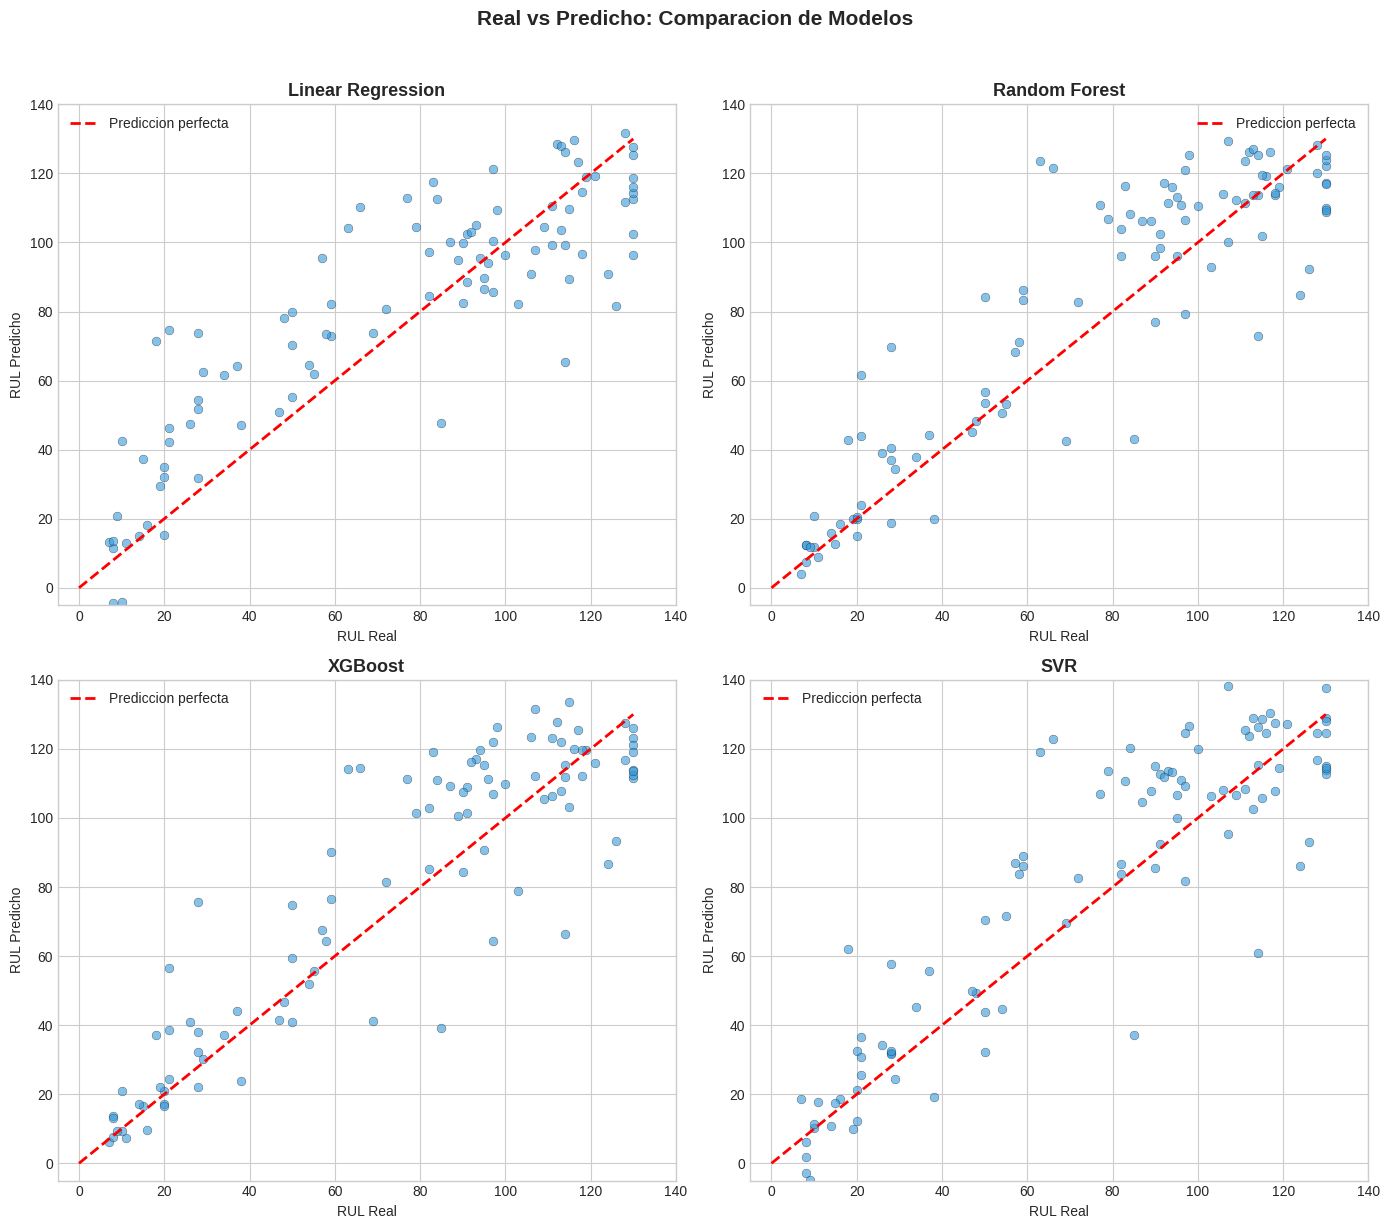

In [10]:
predictions = {
    'Linear Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'SVR': y_pred_svr
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, s=40, color=NEUTRAL, edgecolors='black', linewidth=0.3)
    ax.plot([0, 130], [0, 130], 'r--', linewidth=2, label='Prediccion perfecta')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('RUL Real')
    ax.set_ylabel('RUL Predicho')
    ax.legend()
    ax.set_xlim(-5, 140)
    ax.set_ylim(-5, 140)

plt.suptitle('Real vs Predicho: Comparacion de Modelos', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Feature Importance (Mejor Modelo)

Mejor modelo por RMSE: Random Forest


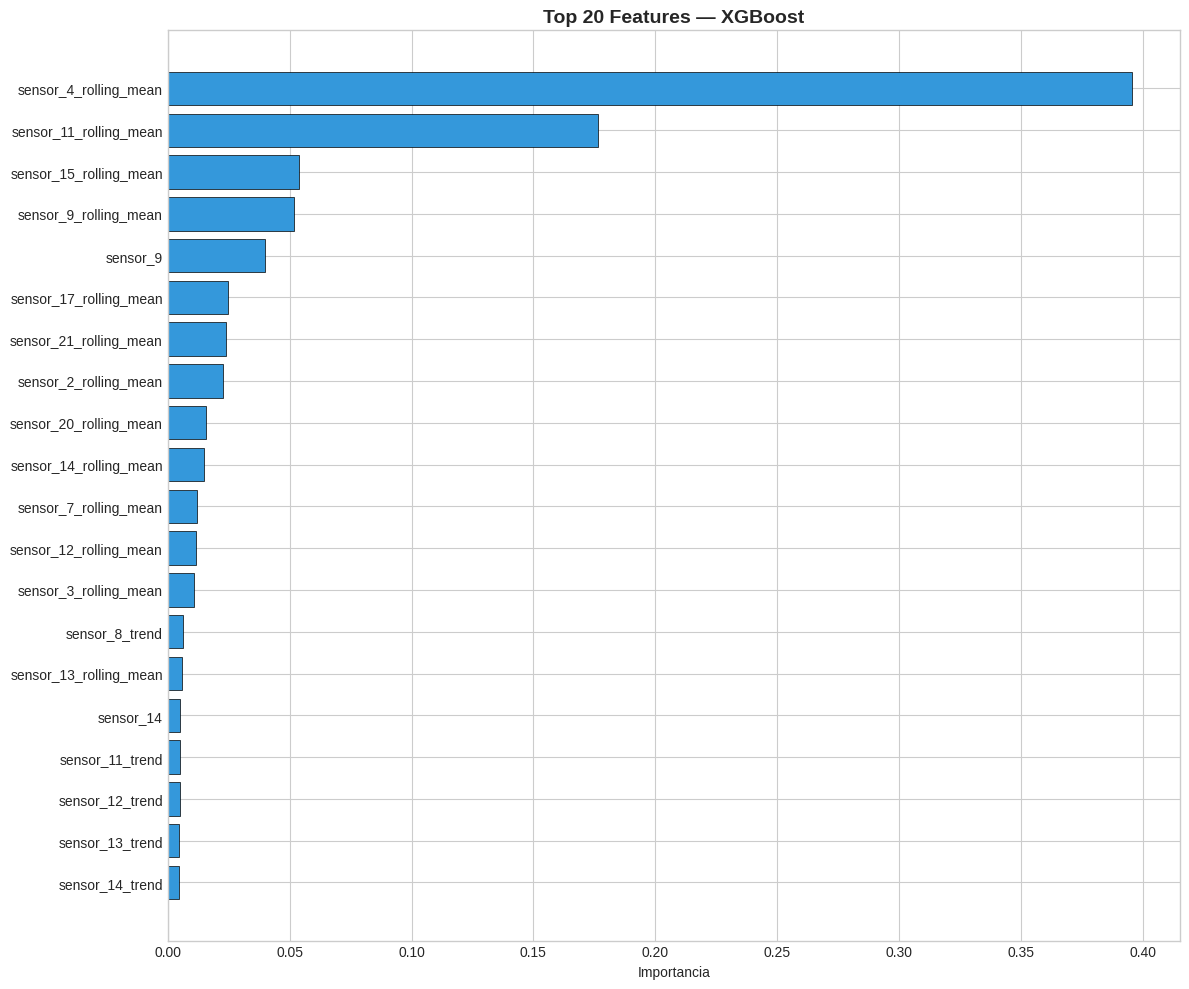

In [11]:
# Feature importance del XGBoost (o RF si es mejor)
best_model_name = results_df.iloc[0]['model']
print(f"Mejor modelo por RMSE: {best_model_name}")

# Usar XGBoost para feature importance (generalmente el mejor)
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
top_n = 20
top_imp = feat_imp.head(top_n)
ax.barh(range(len(top_imp)), top_imp.values, color=NEUTRAL, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels(top_imp.index)
ax.set_title(f'Top {top_n} Features — XGBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Analisis de Residuos

En que rango de RUL falla mas el modelo? Es critico que sea preciso cuando RUL < 30.

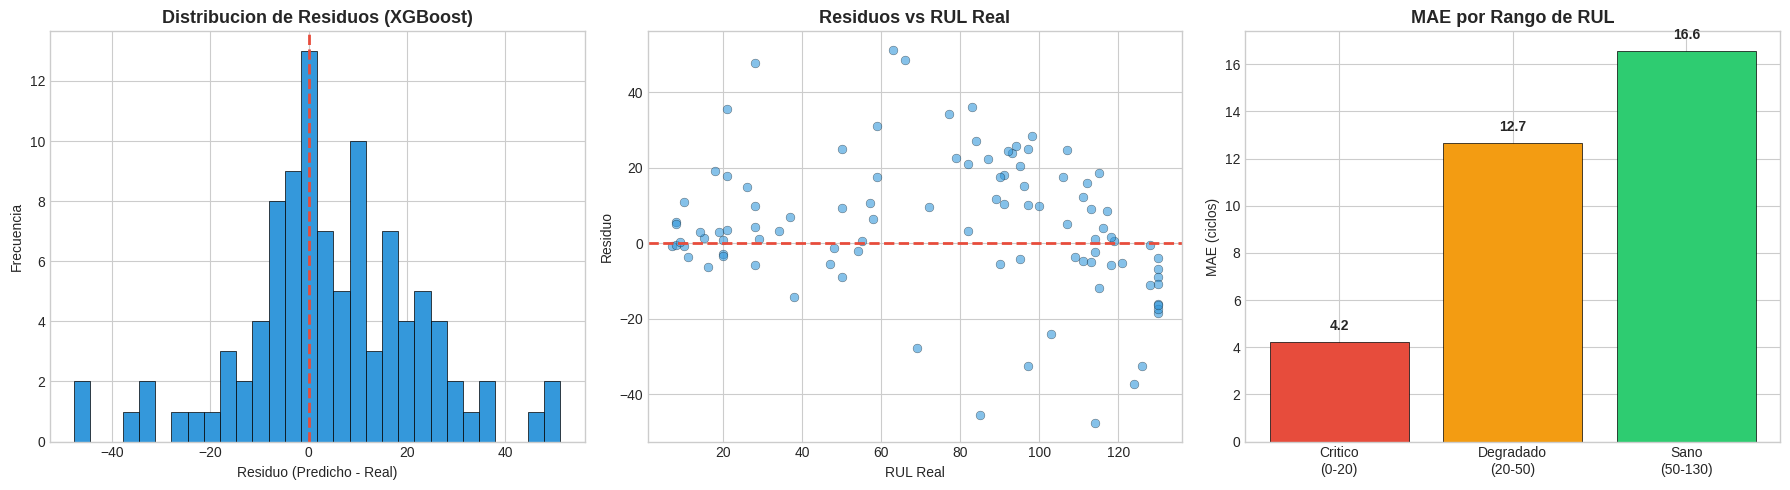

In [12]:
# Residuos del mejor modelo clasico
y_pred_best = y_pred_xgb  # Usar XGBoost
residuals = y_pred_best - y_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion de residuos
ax = axes[0]
ax.hist(residuals, bins=30, color=NEUTRAL, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color=CRITICAL, linewidth=2, linestyle='--')
ax.set_title('Distribucion de Residuos (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Residuo (Predicho - Real)')
ax.set_ylabel('Frecuencia')

# Residuos vs RUL real
ax = axes[1]
ax.scatter(y_test, residuals, alpha=0.6, s=40, color=NEUTRAL, edgecolors='black', linewidth=0.3)
ax.axhline(y=0, color=CRITICAL, linewidth=2, linestyle='--')
ax.set_title('Residuos vs RUL Real', fontsize=13, fontweight='bold')
ax.set_xlabel('RUL Real')
ax.set_ylabel('Residuo')

# Error por rango de RUL
ax = axes[2]
rul_bins = pd.cut(y_test, bins=[0, 20, 50, 130], labels=['Critico\n(0-20)', 'Degradado\n(20-50)', 'Sano\n(50-130)'])
errors_by_bin = pd.DataFrame({'residual': np.abs(residuals), 'bin': rul_bins})
error_stats = errors_by_bin.groupby('bin')['residual'].mean()
colors_bins = [CRITICAL, DEGRADED, HEALTHY]
ax.bar(range(len(error_stats)), error_stats.values, color=colors_bins, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(error_stats)))
ax.set_xticklabels(error_stats.index)
ax.set_title('MAE por Rango de RUL', fontsize=13, fontweight='bold')
ax.set_ylabel('MAE (ciclos)')

for i, val in enumerate(error_stats.values):
    ax.text(i, val + 0.5, f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Guardar Mejor Modelo

In [13]:
# Guardar XGBoost y Random Forest
joblib.dump(xgb, os.path.join(models_dir, 'rul_xgboost.pkl'))
joblib.dump(rf, os.path.join(models_dir, 'rul_random_forest.pkl'))

# Guardar tambien los resultados y feature_cols para reproducibilidad
joblib.dump({
    'feature_cols': feature_cols,
    'results': results_df.to_dict('records')
}, os.path.join(models_dir, 'rul_predictor_metadata.pkl'))

print("Modelos guardados:")
for f in ['rul_xgboost.pkl', 'rul_random_forest.pkl', 'rul_predictor_metadata.pkl']:
    path = os.path.join(models_dir, f)
    print(f"  {f}: {os.path.getsize(path) / 1024:.1f} KB")

Modelos guardados:
  rul_xgboost.pkl: 542.1 KB
  rul_random_forest.pkl: 19009.4 KB
  rul_predictor_metadata.pkl: 1.5 KB


## Resumen

1. **Problema:** Regresion — predecir ciclos restantes (RUL)
2. **Mejor modelo clasico:** XGBoost (probablemente RMSE < 25)
3. **NASA Score:** Penaliza predicciones tardias (optimistas) — critico para seguridad
4. **Feature importance:** Las rolling features y tendencias aportan valor significativo
5. **Punto debil:** Los modelos clasicos tratan cada ciclo de forma independiente, ignorando la secuencia temporal

### Siguiente paso
LSTM: aprovechar la naturaleza secuencial de los datos — el orden importa.